# Validation Pipeline for lenet5

This is validation pipeline is going to be quite similar to the AlexNet pip



In [10]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

Already up to date.


Imported le_net_5 from: /content/4803_project_advanced_neural_networks/model/le_net_5.py
LeNet5 signature: (self, in_channels=1, k_classes=10, dropout=0.0)
Device: cuda

Config: lr=0.0001, drop=0.0
  Fold 1/3: val_acc=93.02%
  Fold 2/3: val_acc=92.80%
  Fold 3/3: val_acc=91.86%

Config: lr=0.0001, drop=0.2
  Fold 1/3: val_acc=92.08%
  Fold 2/3: val_acc=92.25%
  Fold 3/3: val_acc=92.11%

Config: lr=0.0001, drop=0.4
  Fold 1/3: val_acc=91.11%
  Fold 2/3: val_acc=91.78%
  Fold 3/3: val_acc=91.20%

Config: lr=0.0001, drop=0.6
  Fold 1/3: val_acc=90.52%
  Fold 2/3: val_acc=90.80%
  Fold 3/3: val_acc=90.59%

Config: lr=0.0001, drop=0.8
  Fold 1/3: val_acc=86.77%
  Fold 2/3: val_acc=87.00%
  Fold 3/3: val_acc=87.28%

Config: lr=0.0005, drop=0.0
  Fold 1/3: val_acc=97.78%
  Fold 2/3: val_acc=97.72%
  Fold 3/3: val_acc=97.22%

Config: lr=0.0005, drop=0.2
  Fold 1/3: val_acc=97.61%
  Fold 2/3: val_acc=97.59%
  Fold 3/3: val_acc=97.06%

Config: lr=0.0005, drop=0.4
  Fold 1/3: val_acc=97.28%
  Fol

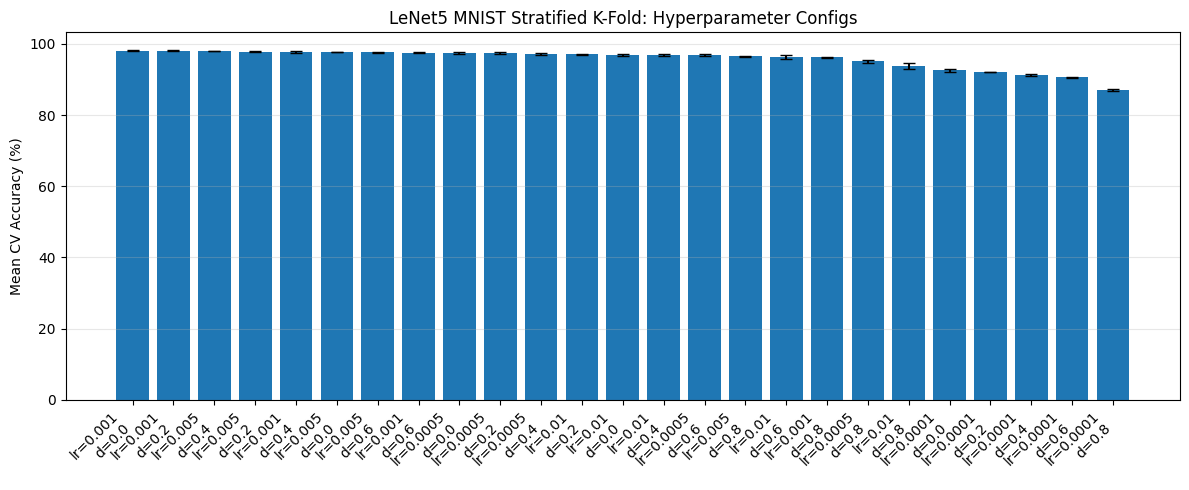

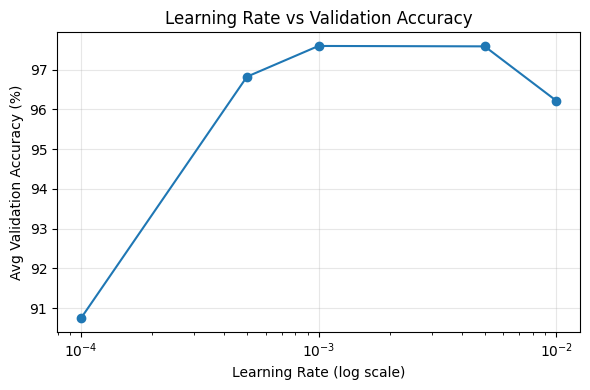

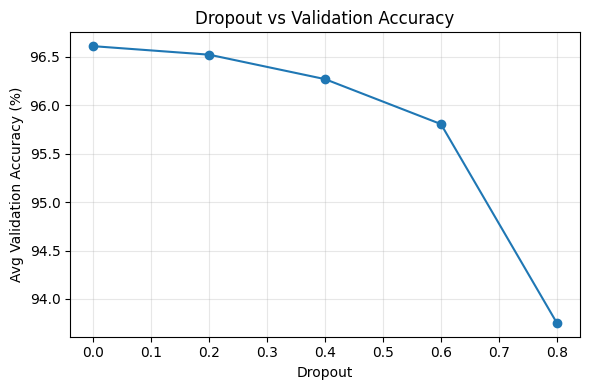


Best configuration:
learning_rate        0.001
dropout                0.0
mean_cv_acc      98.151667
std_cv_acc        0.203729
Name: 0, dtype: object


In [13]:
# Single-cell MNIST K-Fold validation for LeNet5
# Focus hyperparameters: learning rate + dropout

import sys
import inspect
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedKFold

# Repo/module setup
repo_root = Path("/content/4803_project_advanced_neural_networks")
model_dir = repo_root / "model"
if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

import le_net_5
importlib.reload(le_net_5)
LeNet5 = le_net_5.LeNet5

print("Imported le_net_5 from:", le_net_5.__file__)
print("LeNet5 signature:", inspect.signature(LeNet5.__init__))
# Reproducibility + device
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# MNIST dataset (LeNet-friendly 32x32)
mnist_transform = transforms.Compose(
    [
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
# Optional speed-up for Colab experiments; set to None for full 60k
cv_dataset = train_data
cv_targets = np.array(train_data.targets)
# CV hyperparameter grid
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
dropout_values = [0.0, 0.2, 0.4, 0.6,0.8,]
n_splits = 3
epochs = 4
batch_size = 128
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
results = []
# Train/eval helpers
def evaluate_top1(model: nn.Module, loader: DataLoader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / max(total, 1)

# Stratified K-Fold loop
for lr in learning_rates:
    for dropout in dropout_values:
        fold_scores = []
        config_name = f"lr={lr}, drop={dropout}"
        print(f"\nConfig: {config_name}")
        for fold_id, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_targets)), cv_targets), start=1):
            train_subset = Subset(cv_dataset, train_idx.tolist())
            val_subset = Subset(cv_dataset, val_idx.tolist())

            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)

            model = LeNet5(in_channels=1, k_classes=10, dropout=dropout).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            loss_fn = nn.CrossEntropyLoss()
            for _ in range(epochs):
                model.train()
                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)
                    optimizer.zero_grad()
                    loss = loss_fn(model(images), labels)
                    loss.backward()
                    optimizer.step()

            fold_acc = evaluate_top1(model, val_loader)
            fold_scores.append(fold_acc)
            print(f"  Fold {fold_id}/{n_splits}: val_acc={fold_acc:.2f}%")
        results.append(
            {
                "learning_rate": lr,
                "dropout": dropout,
                "mean_cv_acc": float(np.mean(fold_scores)),
                "std_cv_acc": float(np.std(fold_scores)),
                "fold_scores": fold_scores,
            }
        )

# Results + plots
results_df = pd.DataFrame(results).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
print("\nTop configurations:")
print(results_df[["learning_rate", "dropout", "mean_cv_acc", "std_cv_acc"]].head(10))

# Plot 1: Full config comparison
plt.figure(figsize=(12, 5))
labels = [f"lr={r.learning_rate}\nd={r.dropout}" for r in results_df.itertuples()]
plt.bar(range(len(results_df)), results_df["mean_cv_acc"], yerr=results_df["std_cv_acc"], capsize=4)
plt.xticks(range(len(results_df)), labels, rotation=45, ha="right")
plt.ylabel("Mean CV Accuracy (%)")
plt.title("LeNet5 MNIST Stratified K-Fold: Hyperparameter Configs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Learning rate effect (averaged across dropout)
lr_effect = results_df.groupby("learning_rate", as_index=False)["mean_cv_acc"].mean().sort_values("learning_rate")
plt.figure(figsize=(6, 4))
plt.plot(lr_effect["learning_rate"], lr_effect["mean_cv_acc"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Avg Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Dropout effect (averaged across learning rate)
dropout_effect = results_df.groupby("dropout", as_index=False)["mean_cv_acc"].mean().sort_values("dropout")
plt.figure(figsize=(6, 4))
plt.plot(dropout_effect["dropout"], dropout_effect["mean_cv_acc"], marker="o")
plt.xlabel("Dropout")
plt.ylabel("Avg Validation Accuracy (%)")
plt.title("Dropout vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print("\nBest configuration:")
print(best[["learning_rate", "dropout", "mean_cv_acc", "std_cv_acc"]])